
# Технологический практикум — Этап 1 (Python)
**Датасет:** Spotify Songs  
**Файл данных :** `data/spotify_songs.csv`  

In [68]:
import os
import matplotlib.pyplot as plt

FIG_DIR = "картинки"
os.makedirs(FIG_DIR, exist_ok=True)

def savefig(name, dpi=150):
    """Сохраняет текущую (active) фигуру в папку картинки/"""
    path = os.path.join(FIG_DIR, name)
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print("saved:", path)



In [69]:

import os, sys, math, pathlib, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import gaussian_kde
warnings.filterwarnings("ignore")

plt.rcParams.update({
    "figure.figsize": (7.5, 4.2),
    "axes.facecolor": "white",
    "figure.facecolor": "white",
    "axes.grid": True,
    "grid.linestyle": ":",
    "grid.alpha": 0.45,
    "axes.titleweight": "semibold",
    "axes.labelsize": 11,
    "axes.titlesize": 13,
    "xtick.labelsize": 9,
    "ytick.labelsize": 9,
    "legend.frameon": False,
    "savefig.dpi": 150,
})

CANDIDATES = ["data/spotify_songs.csv", "spotify_songs.csv", "../spotify_songs.csv", "/mnt/data/spotify_songs.csv"]
for _p in CANDIDATES:
    if os.path.exists(_p):
        DATA_PATH = _p
        break
else:
    DATA_PATH = "data/spotify_songs.csv"

print("Using DATA_PATH:", DATA_PATH)

df = pd.read_csv(DATA_PATH)
print("Shape:", df.shape)
print("Columns:", list(df.columns)[:12], "...")

default_candidates = [
    "danceability","energy","loudness","speechiness","acousticness",
    "instrumentalness","liveness","valence","tempo","duration_ms","track_popularity"
]
num_cols = [c for c in default_candidates if c in df.columns]
cat_cols = [c for c in ["playlist_genre","playlist_subgenre","mode","key","explicit","language"] if c in df.columns]

print("Numeric cols:", num_cols)
print("Categorical-like cols:", cat_cols)


Using DATA_PATH: data/spotify_songs.csv
Shape: (18454, 25)
Columns: ['track_id', 'track_name', 'track_artist', 'lyrics', 'track_popularity', 'track_album_id', 'track_album_name', 'track_album_release_date', 'playlist_name', 'playlist_id', 'playlist_genre', 'playlist_subgenre'] ...
Numeric cols: ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_ms', 'track_popularity']
Categorical-like cols: ['playlist_genre', 'playlist_subgenre', 'mode', 'key', 'language']


In [70]:
import os
import matplotlib.pyplot as plt

FIG_DIR = "картинки"
os.makedirs(FIG_DIR, exist_ok=True)

def savefig(name, dpi=150):
    """Сохраняет текущую фигуру в папку картинки/"""
    path = os.path.join(FIG_DIR, name)
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print("saved:", path)


## 1) Описание данных, основные характеристики и пропуски

,count,mean,std,min,25%,50%,75%,max
danceability,18454.0,0.644066,0.150071,0.098500,0.5460,0.660000,0.75500,0.979
energy,18454.0,0.692289,0.180635,0.016700,0.5730,0.715000,0.83500,1.000
loudness,18454.0,-6.769159,2.920757,-34.283000,-8.2490,-6.227000,-4.71900,1.275
speechiness,18454.0,0.106192,0.102291,0.022400,0.0397,0.060300,0.13000,0.918
acousticness,18454.0,0.175348,0.217795,0.000001,0.0161,0.081900,0.25400,0.992
instrumentalness,18454.0,0.051216,0.168263,0.000000,0.0000,0.000009,0.00172,0.987
liveness,18454.0,0.189593,0.153751,0.009360,0.0927,0.128000,0.24600,0.996
valence,18454.0,0.520598,0.228716,0.000010,0.3450,0.522000,0.70000,0.991
tempo,18454.0,120.812167,27.586424,37.114000,98.8560,120.045000,135.98400,214.047
duration_ms,18454.0,230319.306763,57255.086685,31893.000000,193230.2500,221340.000000,258078.25000,517810.000


lyrics                      0.014089
language                    0.014089
track_id                    0.000000
track_artist                0.000000
track_name                  0.000000
track_album_id              0.000000
track_album_name            0.000000
track_album_release_date    0.000000
track_popularity            0.000000
playlist_name               0.000000
playlist_id                 0.000000
playlist_subgenre           0.000000
playlist_genre              0.000000
energy                      0.000000
key                         0.000000
loudness                    0.000000
danceability                0.000000
mode                        0.000000
speechiness                 0.000000
instrumentalness            0.000000
dtype: float64

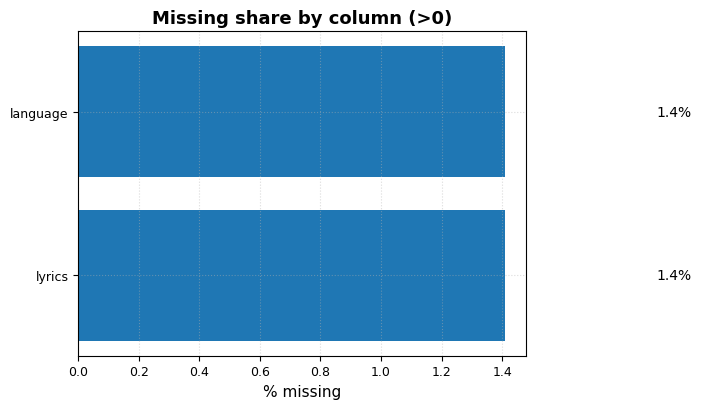

In [71]:

desc = df[num_cols].describe().T
display(desc)

missing_share = df.isna().mean().sort_values(ascending=False)
display(missing_share.head(20))

ms = (missing_share[missing_share>0]*100).sort_values(ascending=True)
if len(ms):
    plt.figure()
    plt.barh(ms.index, ms.values)
    plt.xlabel("% missing")
    plt.title("Missing share by column (>0)")
    for y, v in enumerate(ms.values):
        plt.text(v+0.5, y, f"{v:.1f}%", va="center")
    plt.tight_layout()
    plt.show()
else:
    print("No missing values detected (at column level).")


## 2) Ядерные оценки плотности (KDE) по числовым признакам

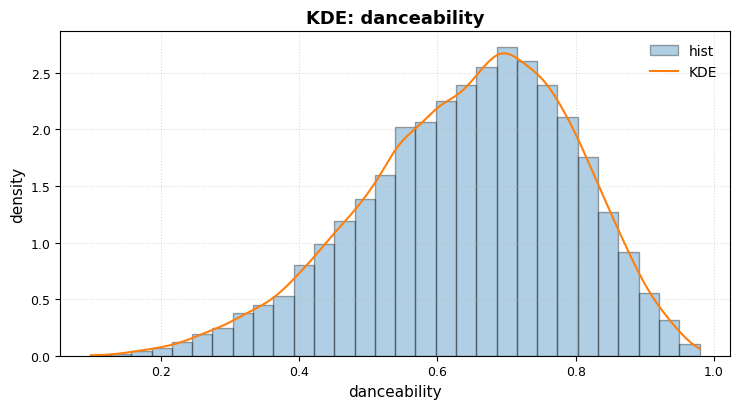

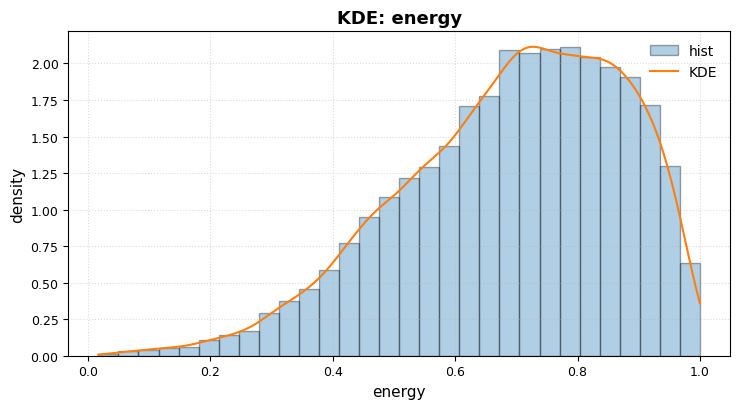

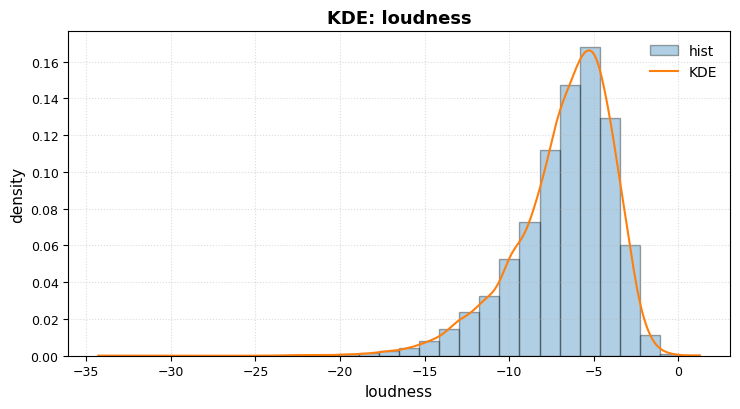

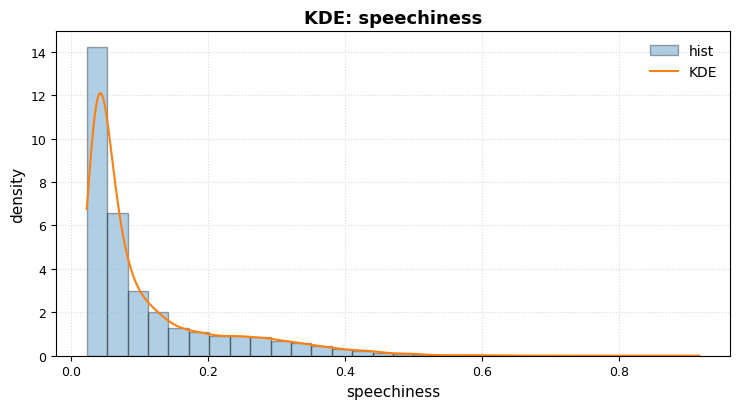

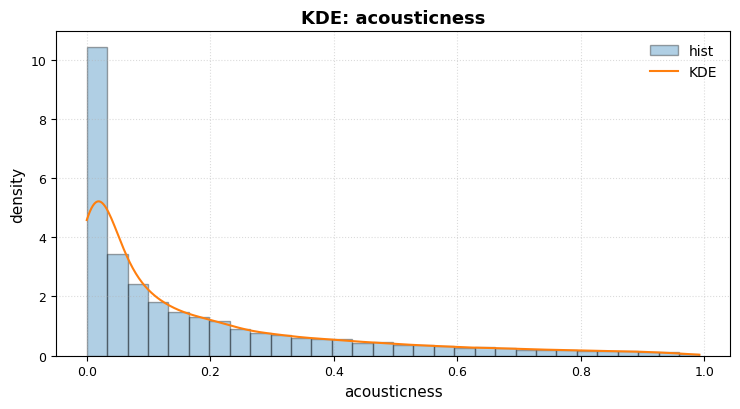

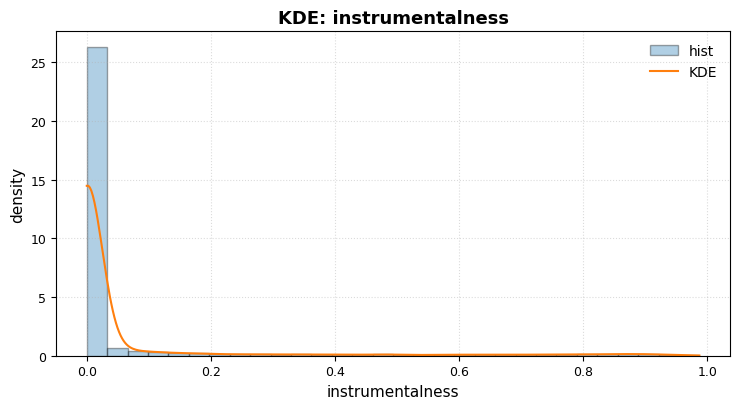

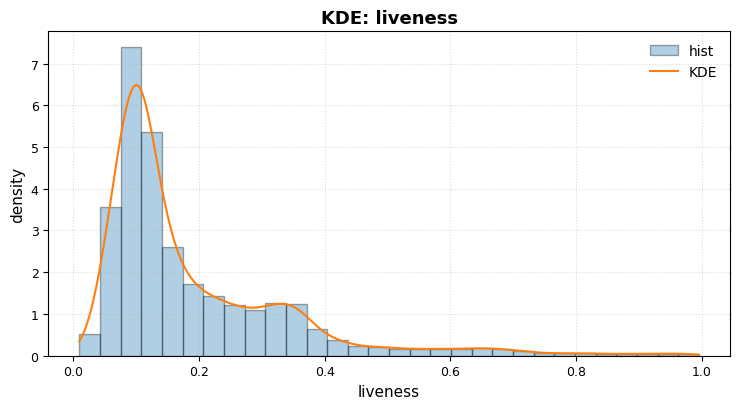

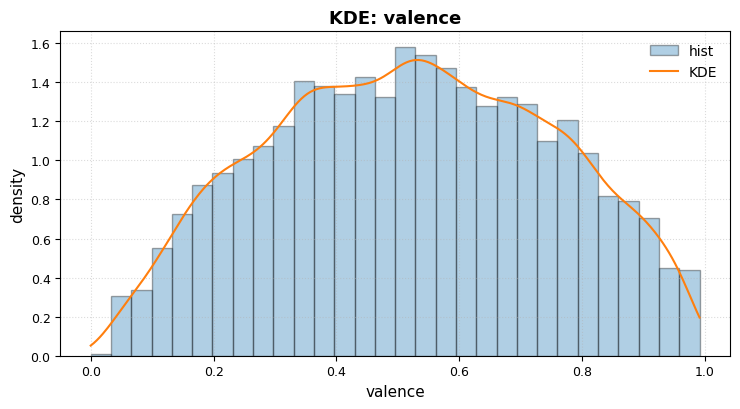

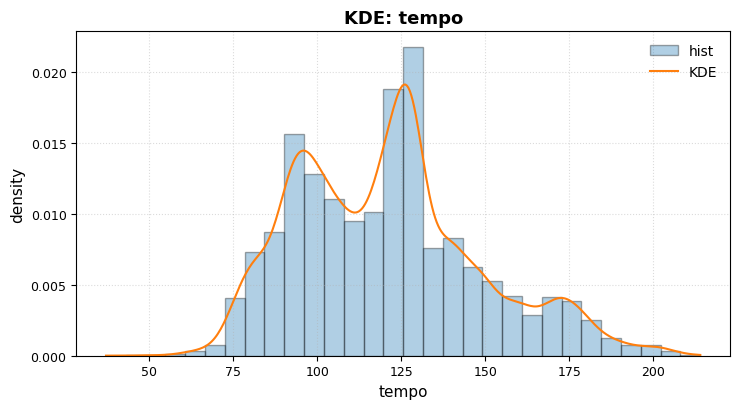

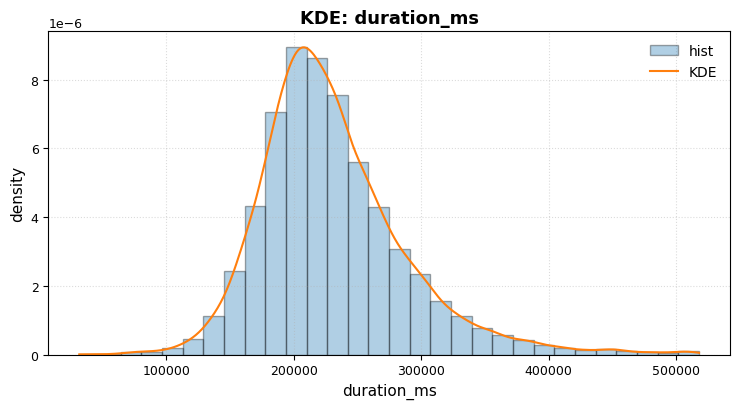

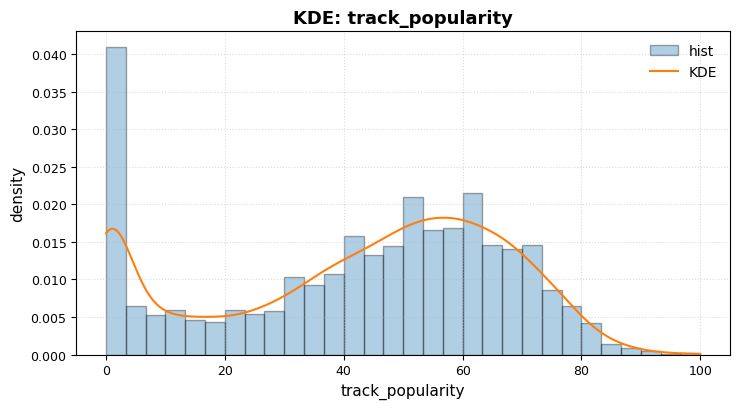

In [72]:

for c in num_cols:
    x = pd.to_numeric(df[c], errors="coerce").dropna().values
    if len(x) < 10 or np.all(x == x[0]):
        continue
    kde = gaussian_kde(x)
    xs = np.linspace(np.min(x), np.max(x), 400)
    plt.figure()
    bins = 30 if len(x)>500 else 20
    plt.hist(x, bins=bins, density=True, alpha=0.35, edgecolor="black", label="hist")
    plt.plot(xs, kde(xs), label="KDE")
    plt.title(f"KDE: {c}")
    plt.xlabel(c); plt.ylabel("density")
    plt.legend()
    plt.tight_layout()
    plt.show()


## 3) Boxplot, Stripchart (все числовые) + отдельный boxplot для duration_ms

saved: картинки\boxplots_all_numeric.png


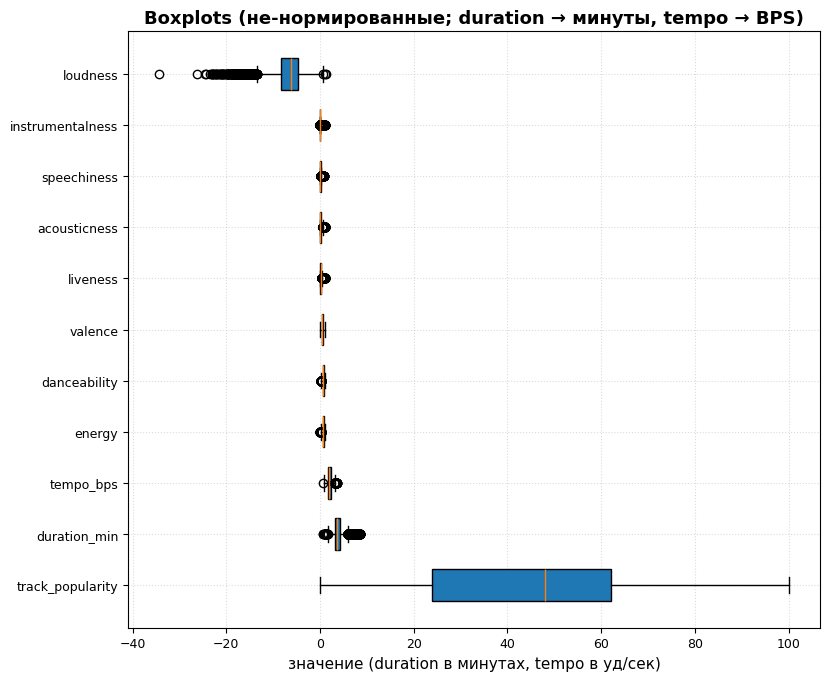

saved: картинки\stripchart_all_numeric.png


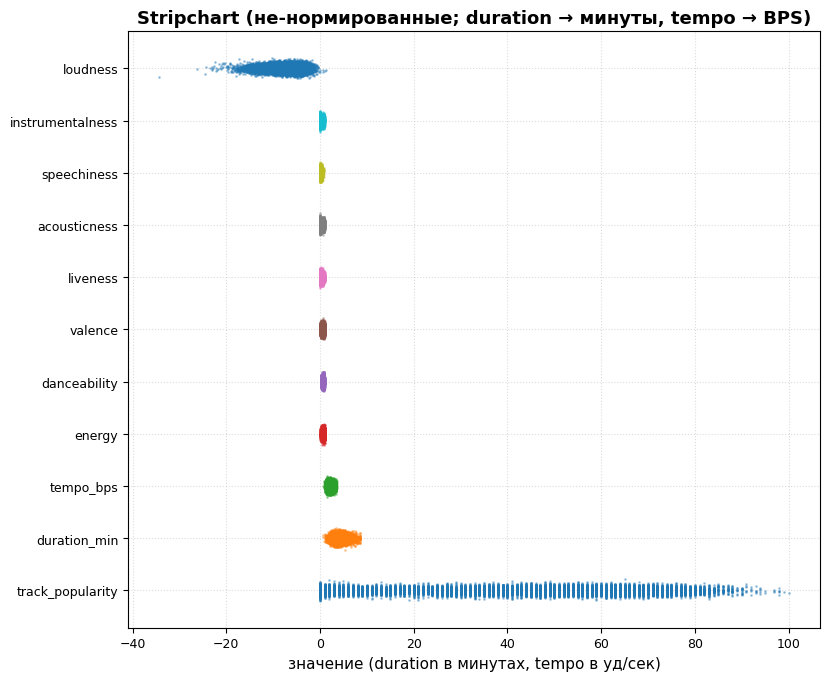

saved: картинки\boxplots_standardized_zscore.png


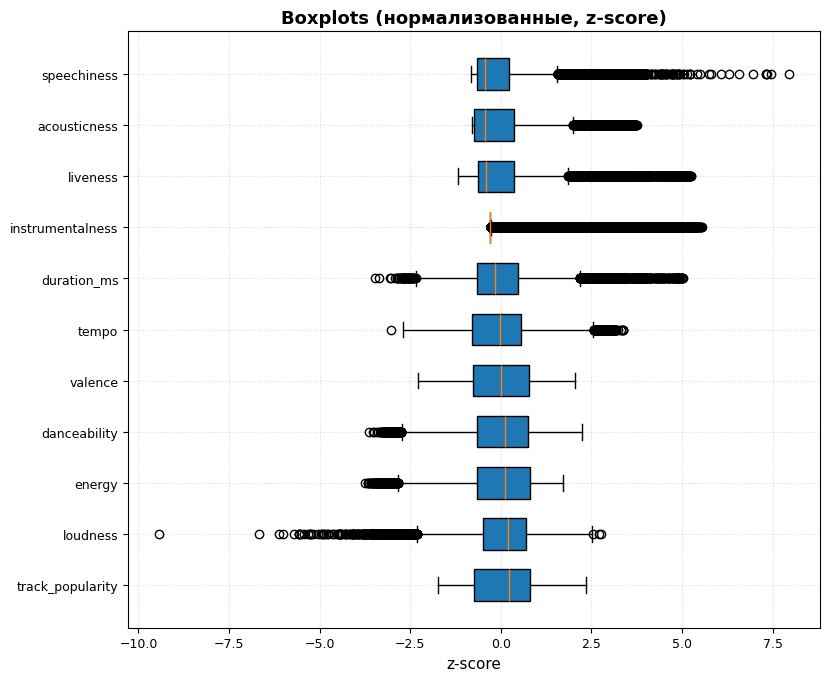

In [73]:
from sklearn.preprocessing import StandardScaler




USE_LOG_FOR_SKEWED = False

SKEWED = [c for c in ["acousticness","instrumentalness","speechiness","liveness","valence"] if c in df.columns]

df_vis = df.copy()
num_cols_vis = [*num_cols]

# duration: миллисекунды → минуты
if "duration_ms" in df_vis.columns:
    df_vis["duration_min"] = pd.to_numeric(df_vis["duration_ms"], errors="coerce") / 60000.0
    num_cols_vis = [c for c in num_cols_vis if c != "duration_ms"] + ["duration_min"]

# tempo: BPM → BPS (beats per second)
if "tempo" in df_vis.columns:
    df_vis["tempo_bps"] = pd.to_numeric(df_vis["tempo"], errors="coerce") / 60.0
    num_cols_vis = [c for c in num_cols_vis if c != "tempo"] + ["tempo_bps"]

long_vis = df_vis[num_cols_vis].melt(var_name="feature", value_name="value").dropna()
order_by_median = (
    long_vis.groupby("feature")["value"]
    .median()
    .sort_values(ascending=False)
    .index
)
long_vis["feature"] = pd.Categorical(long_vis["feature"], categories=list(order_by_median), ordered=True)

plt.figure(figsize=(8.4, max(4.2, 0.52*len(order_by_median)+1.2)))
for i, feat in enumerate(order_by_median):
    vals = long_vis.loc[long_vis["feature"]==feat, "value"].values
    plt.boxplot(
        vals, vert=False, positions=[i], widths=0.62, patch_artist=True,
        manage_ticks=False, showfliers=True
    )
plt.yticks(np.arange(len(order_by_median)), order_by_median)
plt.title("Boxplots (не-нормированные; duration → минуты, tempo → BPS)")
plt.xlabel("значение (duration в минутах, tempo в уд/сек)")
plt.tight_layout()
savefig("boxplots_all_numeric.png")

plt.show()

plt.figure(figsize=(8.4, max(4.2, 0.52*len(order_by_median)+1.2)))
for i, feat in enumerate(order_by_median):
    vals = long_vis.loc[long_vis["feature"]==feat, "value"].values
    y = np.random.normal(loc=i, scale=0.05, size=len(vals))
    plt.plot(vals, y, ".", alpha=0.35, markersize=2)
plt.yticks(np.arange(len(order_by_median)), order_by_median)
plt.title("Stripchart (не-нормированные; duration → минуты, tempo → BPS)")
plt.xlabel("значение (duration в минутах, tempo в уд/сек)")
plt.tight_layout()
savefig("stripchart_all_numeric.png")

plt.show()

scaler = StandardScaler()
scaled = pd.DataFrame(scaler.fit_transform(df[num_cols]), columns=num_cols)
long_scaled = scaled.melt(var_name="feature", value_name="z").dropna()
order_by_med_z = (
    long_scaled.groupby("feature")["z"]
    .median()
    .sort_values(ascending=False)
    .index
)
long_scaled["feature"] = pd.Categorical(long_scaled["feature"], categories=list(order_by_med_z), ordered=True)

plt.figure(figsize=(8.4, max(4.2, 0.52*len(order_by_med_z)+1.2)))
for i, feat in enumerate(order_by_med_z):
    vals = long_scaled.loc[long_scaled["feature"]==feat, "z"].values
    plt.boxplot(
        vals, vert=False, positions=[i], widths=0.62, patch_artist=True,
        manage_ticks=False, showfliers=True
    )
plt.yticks(np.arange(len(order_by_med_z)), order_by_med_z)
plt.title("Boxplots (нормализованные, z-score)")
plt.xlabel("z-score")
plt.tight_layout()
savefig("boxplots_standardized_zscore.png")

plt.show()

if USE_LOG_FOR_SKEWED and len(SKEWED) > 0:
    long_log = []
    for c in SKEWED:
        x = pd.to_numeric(df[c], errors="coerce")
        x = x[x > 0]  # лог определён только для x>0
        if len(x) < 5:
            continue
        long_log.append(pd.DataFrame({"feature": f"{c} (log1p)", "value": np.log1p(x)}))
    if long_log:
        long_log = pd.concat(long_log, ignore_index=True)
        order_log = long_log.groupby("feature")["value"].median().sort_values(ascending=False).index
        long_log["feature"] = pd.Categorical(long_log["feature"], categories=list(order_log), ordered=True)

        plt.figure(figsize=(7.8, max(3.8, 0.5*len(order_log)+1.0)))
        for i, feat in enumerate(order_log):
            vals = long_log.loc[long_log["feature"]==feat, "value"].values
            plt.boxplot(vals, vert=False, positions=[i], widths=0.6, patch_artist=True,
                        manage_ticks=False, showfliers=True)
        plt.yticks(np.arange(len(order_log)), order_log)
        plt.title("Boxplots (лог-преобразование для правоскосых фич)")
        plt.xlabel("log1p(value)")
        plt.tight_layout()
        savefig("boxplots_log1p_skewed.png")

        plt.show()


## 3b) Dotchart & CD-plot analog

saved: картинки\dotchart_danceability_by_playlist_subgenre.png


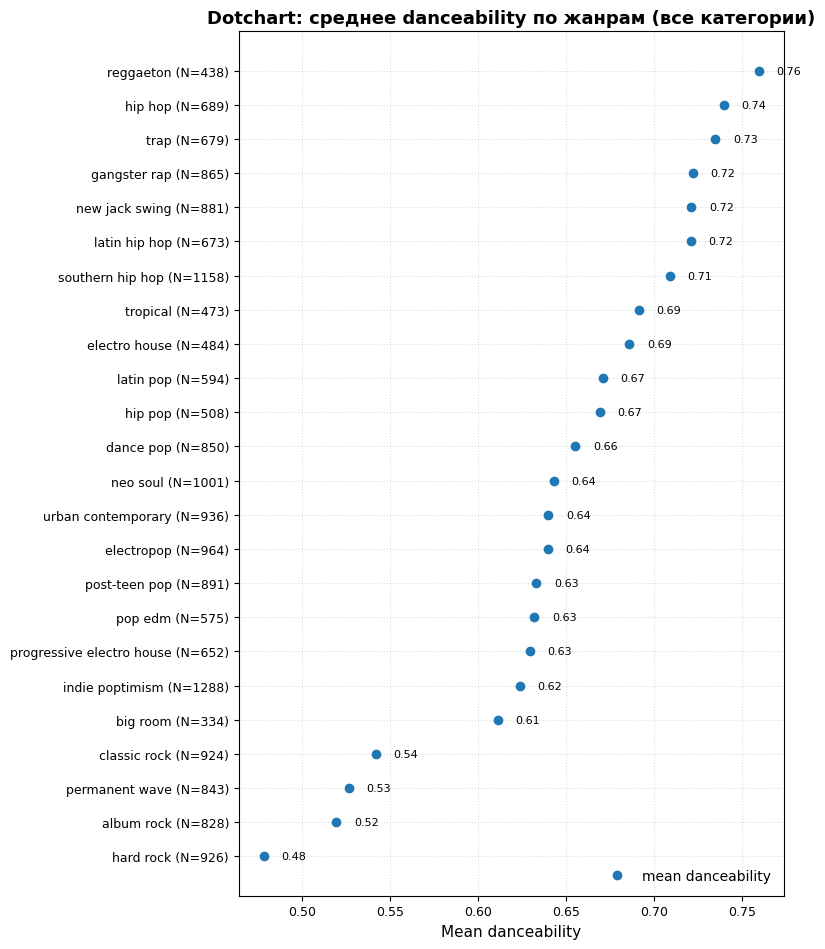

saved: картинки\cdplot_popularity_by_playlist_subgenre.png


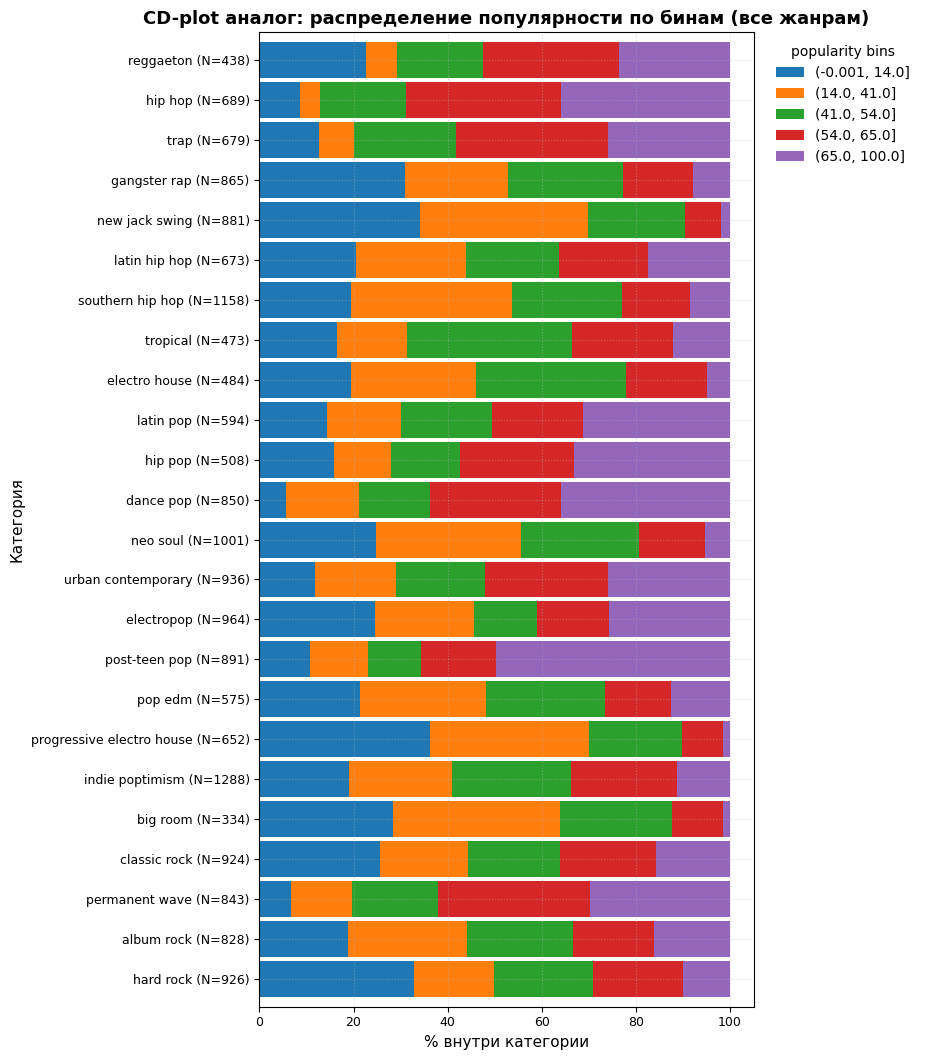

In [74]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

GROUP_COL = "playlist_subgenre"      # можно: "playlist_genre"
FEATURE_FOR_DOT = "danceability"        # можно: 'valence', 'loudness' и т.д.
SORT_BY = "mean"
SHOW_EMPTY = True 
MIN_COUNT = 0

if GROUP_COL not in df.columns:
    raise ValueError(f"Колонки {GROUP_COL} нет в данных.")

grp_counts = (
    df[GROUP_COL]
      .astype(str).replace({"nan": np.nan})
      .value_counts(dropna=True)
)

all_cats = grp_counts.index.to_numpy()
all_counts = grp_counts.to_dict()

if FEATURE_FOR_DOT in df.columns:
    tmp = df[[GROUP_COL, FEATURE_FOR_DOT]].copy()
    tmp[FEATURE_FOR_DOT] = pd.to_numeric(tmp[FEATURE_FOR_DOT], errors="coerce")

    mean_by = (
        tmp.groupby(GROUP_COL, dropna=True)[FEATURE_FOR_DOT]
           .mean()
           .reindex(all_cats)
    )

    # Сортировка категорий
    if SORT_BY == "mean":
        order = mean_by.fillna(mean_by.mean()).sort_values().index
    else:
        order = np.sort(all_cats)

    labels = [f"{c} (N={all_counts.get(c,0)})" for c in order]

    fig_h = max(4.2, 0.35*len(order)+1.2)
    plt.figure(figsize=(8.2, fig_h))

    y = np.arange(len(order))
    has_data_mask = ~mean_by.loc[order].isna().values
    if has_data_mask.any():
        vals = mean_by.loc[order][has_data_mask].values
        y_idx = y[has_data_mask]
        plt.plot(vals, y_idx, "o", label=f"mean {FEATURE_FOR_DOT}")
        for xi, yi in zip(vals, y_idx):
            plt.text(xi + 0.01, yi, f"{xi:.2f}", va="center", fontsize=8)

    # категории без данных
    if SHOW_EMPTY and (~has_data_mask).any():
        y_no = y[~has_data_mask]
        x_stub = np.zeros_like(y_no, dtype=float)
        plt.plot(x_stub, y_no, "x", color="gray", label="нет данных")
        for xi, yi in zip(x_stub, y_no):
            plt.text(xi + 0.01, yi, "нет данных", va="center", fontsize=8, color="gray")

    plt.yticks(y, labels)
    plt.xlabel(f"Mean {FEATURE_FOR_DOT}")
    title_grp = "жанрам" if GROUP_COL == "playlist_subgenre" else "поджанрам"
    plt.title(f"Dotchart: среднее {FEATURE_FOR_DOT} по {title_grp} (все категории)")
    plt.legend(loc="lower right")
    plt.tight_layout()
    savefig(f"dotchart_{FEATURE_FOR_DOT}_by_{GROUP_COL}.png") 
    plt.show()

if "track_popularity" in df.columns:
    d = df[[GROUP_COL, "track_popularity"]].copy()
    d = d.dropna(subset=[GROUP_COL])  # группа обязательна
    d["track_popularity"] = pd.to_numeric(d["track_popularity"], errors="coerce")

    d_valid = d.dropna(subset=["track_popularity"])
    if len(d_valid) > 0:
        try:
            d_valid["pop_bin"] = pd.qcut(d_valid["track_popularity"], q=5, duplicates="drop")
            bin_cats = d_valid["pop_bin"].cat.categories
        except Exception:
            bins = [-0.1, 20, 40, 60, 80, 100]
            d_valid["pop_bin"] = pd.cut(d_valid["track_popularity"], bins=bins, include_lowest=True)
            bin_cats = d_valid["pop_bin"].cat.categories

        ct = (
            d_valid.groupby([GROUP_COL, "pop_bin"])["track_popularity"]
                   .count()
                   .unstack("pop_bin")
        )
        ct = ct.reindex(index=all_cats, columns=bin_cats, fill_value=0)

        row_sums = ct.sum(axis=1).replace(0, np.nan)
        ct_pct = (ct.T / row_sums).T.fillna(0.0)

        ct_pct = ct_pct.loc[order]

        fig_h = max(4.4, 0.40*len(order)+1.1)
        ax = ct_pct.mul(100).plot(
            kind="barh", stacked=True, figsize=(9.4, fig_h), width=0.9, edgecolor="none"
        )
        ax.set_xlabel("% внутри категории")
        ax.set_ylabel("Категория")
        ax.set_yticklabels(labels)  # метки с N
        ttl = "жанрам" if GROUP_COL == "playlist_subgenre" else "поджанрам"
        ax.set_title(f"CD-plot аналог: распределение популярности по бинам (все {ttl})")
        ax.legend(title="popularity bins", bbox_to_anchor=(1.02, 1), loc="upper left")
        plt.tight_layout()
        savefig(f"cdplot_popularity_by_{GROUP_COL}.png") 

        plt.show()
    else:
        fig_h = max(4.2, 0.40*len(all_cats)+1.0)
        plt.figure(figsize=(9.4, fig_h))
        y = np.arange(len(all_cats))
        plt.barh(y, np.zeros_like(y))
        plt.yticks(y, [f"{c} (N={all_counts.get(c,0)})" for c in all_cats])
        plt.xlabel("% внутри категории")
        plt.title("CD-plot: нет валидных значений track_popularity (все категории)")
        plt.tight_layout()
        savefig(f"cdplot_empty_popularity_by_{GROUP_COL}.png")
        plt.show()


## 4) Исследуем, насколько распределения признаков tempo (темп песни, BPM) и loudness (громкость, dB) близки к нормальному:

Проверка распределения на нормальность

Для оценки, насколько данные о песнях имеют нормальное распределение, рассмотрим две количественные характеристики треков – темп (Tempo, удары в минуту, BPM) и громкость (Loudness, в децибелах dB).

saved: картинки\hist_kde_tempo.png


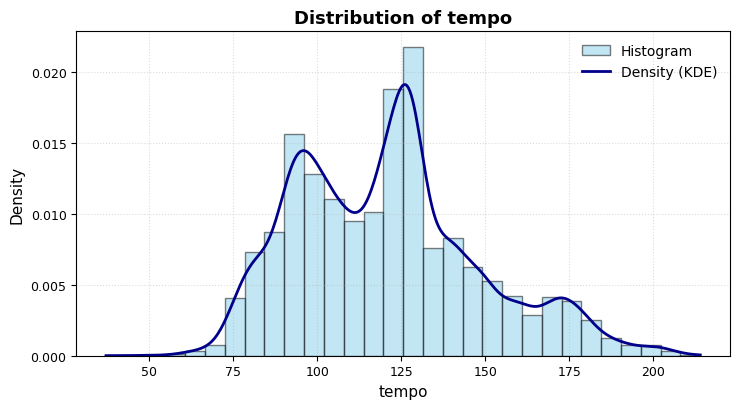

saved: картинки\qq_tempo.png


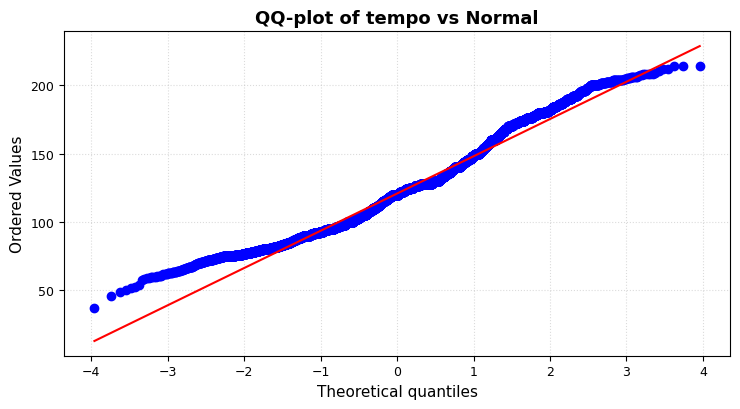

tempo: Shapiro-Wilk p-value = 6.910e-30
tempo: Anderson-Darling statistic = 131.525
    Critical values (AD): {np.float64(15.0): np.float64(0.576), np.float64(10.0): np.float64(0.656), np.float64(5.0): np.float64(0.787), np.float64(2.5): np.float64(0.918), np.float64(1.0): np.float64(1.092)} 

saved: картинки\hist_kde_loudness.png


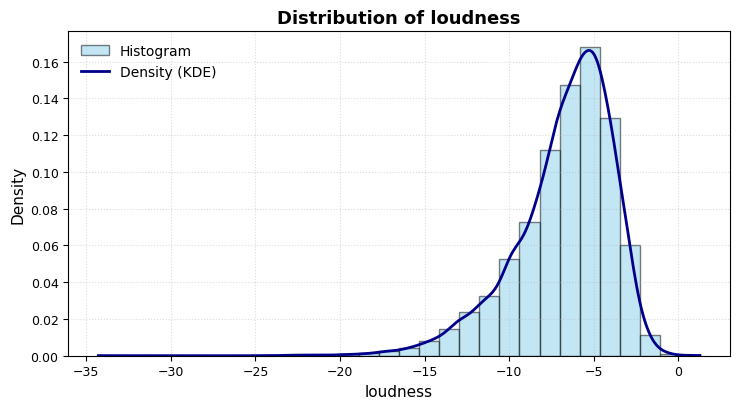

saved: картинки\qq_loudness.png


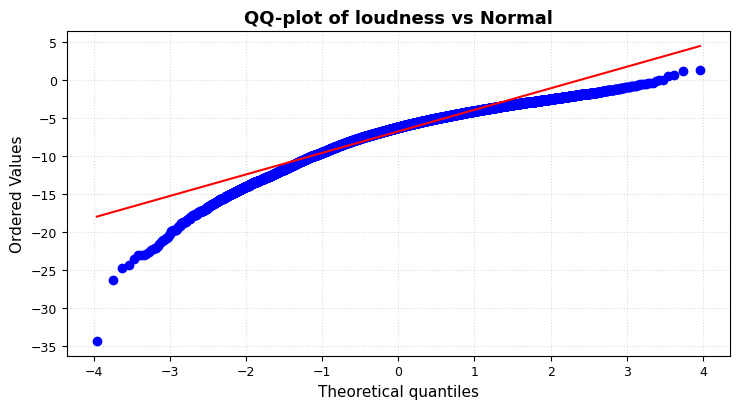

loudness: Shapiro-Wilk p-value = 6.156e-42
loudness: Anderson-Darling statistic = 272.769
    Critical values (AD): {np.float64(15.0): np.float64(0.576), np.float64(10.0): np.float64(0.656), np.float64(5.0): np.float64(0.787), np.float64(2.5): np.float64(0.918), np.float64(1.0): np.float64(1.092)} 



In [75]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import gaussian_kde

features_to_check = ["tempo", "loudness"]
for feat in features_to_check:
    x = pd.to_numeric(df[feat], errors="coerce").dropna().values
    
    #Гистограмма и KDE плотность
    plt.figure()
    bins = 30 if len(x) > 5000 else 20
    plt.hist(x, bins=bins, density=True, alpha=0.5, color="skyblue", edgecolor="black", label="Histogram")
    kde = gaussian_kde(x)
    xs = np.linspace(x.min(), x.max(), 400)
    plt.plot(xs, kde(xs), color="darkblue", linewidth=2, label="Density (KDE)")
    plt.title(f"Distribution of {feat}")
    plt.xlabel(feat); plt.ylabel("Density")
    plt.legend()
    plt.tight_layout()
    savefig(f"hist_kde_{feat}.png")
    plt.show()
    
    #QQ-plot против нормального распределения
    plt.figure()
    stats.probplot(x, dist="norm", plot=plt)
    plt.title(f"QQ-plot of {feat} vs Normal")
    plt.tight_layout()
    savefig(f"qq_{feat}.png")
    plt.show()
    
    #Статистические тесты на нормальность
    #Шапиро-Уилк 
    sample = x if len(x) <= 5000 else np.random.choice(x, 5000, replace=False)
    stat_sw, p_sw = stats.shapiro(sample)
    stat_ad = stats.anderson(x, dist='norm')
    print(f"{feat}: Shapiro-Wilk p-value = {p_sw:.3e}")
    print(f"{feat}: Anderson-Darling statistic = {stat_ad.statistic:.3f}")
    print("    Critical values (AD):", dict(zip(stat_ad.significance_level, stat_ad.critical_values)), "\n")


Распределение темпа песен: гистограмма с ядерной оценкой плотности и Q-Q график нормальности (2ая картинка). На графике видно, что распределение Tempo не похоже на нормальное: оно асимметрично и, вероятно, имеет несколько локальных максимумов. Большинство значений темпа сконцентрированы вокруг ~120 BPM, однако присутствуют заметные «хвосты»: есть группа более медленных треков (60–90 BPM) и небольшой пик более быстрых (выше 150 BPM). Q-Q график подтверждает отклонение от линейности: точки существенно отклоняются от красной диагонали на концах, что указывает на тяжелые хвосты по сравнению с нормальным законом.

Распределение громкости треков: гистограмма (3я картинка) и Q-Q график нормальности. Распределение Loudness также не является нормальным. Форма гистограммы односторонняя: основная масса значений громкости лежит в районе -5…-10 dB, при этом имеется длинный левый хвост (некоторые треки гораздо тише основного потока, до ~-34 dB). Справа распределение обрезано около 0 dB(громкость не может значительно превышать 0 dBFS), поэтому значения близкие к 0 dB выступают природным пределом. На Q-Q графике для громкости наблюдается заметное отклонение точек вниз на левом краю (самые тихие записи значительно «ниже» ожиданий нормального распределения) и излом наверху -> это опять-таки свидетельствует о несоблюдении нормальности.



Статистические тесты подтверждают отклонение от нормальности. Тест Шапиро-Уилка даёт очень малые p-значения (<< 0.05) для обоих признаков, а тест Андерсона-Дарлинга показывает статистику значительно выше критических уровней (на уровне значимости 5% и даже 1%). Это позволяет отвергнуть нулевую гипотезу о нормальном распределении для tempo и loudness. Таким образом, строго говоря, применение критериев Граббса и Диксона к этим данным не полностью обосновано (их допущения нарушены). 

Критерии Граббса и Диксона требуют нормального распределения. В данном случае они неприменимы. 

Поэтому создадим искусственные нормальные данные.


Normality check
x_clean: Shapiro-Wilk p-value = 6.868e-01
x_clean: Anderson-Darling statistic = 0.232
x_with_outlier: Shapiro-Wilk p-value = 4.229e-04
x_with_outlier: Anderson-Darling statistic = 1.066

 Grubbs test 
x_clean: G=1.964, Gcrit=2.908, reject=False, outlier_index=None
x_with_outlier: G=3.865, Gcrit=2.908, reject=True, outlier_index=0

Dixon Q test 
x_clean: Q=0.054, Qcrit=0.260, reject=False, outlier_side=None
x_with_outlier: Q=0.495, Qcrit=0.260, reject=True, outlier_side=high
saved: картинки\synthetic_normal_clean_hist_qq.png


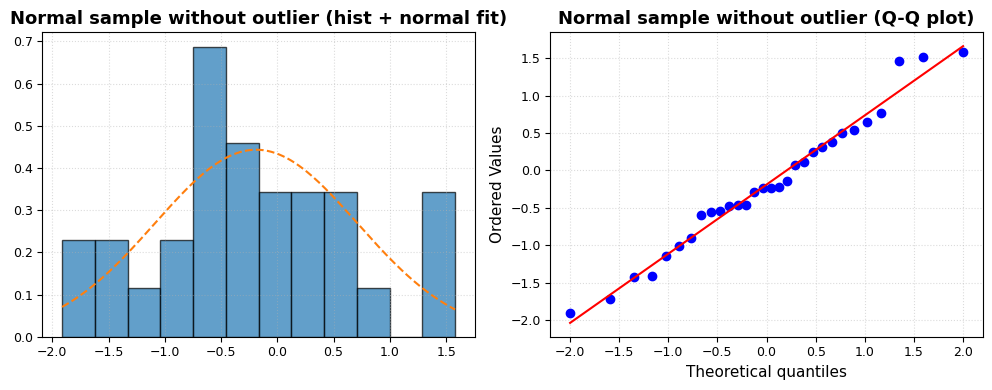

saved: картинки\synthetic_normal_with_outlier_hist_qq.png


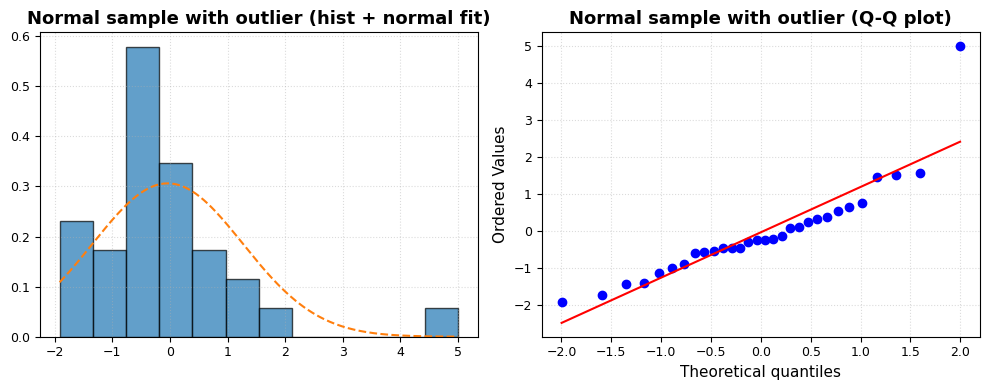

In [76]:
import numpy as np
import scipy.stats as st
import matplotlib.pyplot as plt

np.random.seed(42)

#Генерируем НОРМАЛЬНУЮ выборку малого объёма
n_small = 30
x_clean = np.random.normal(loc=0, scale=1, size=n_small)

#  Создадим выборку с выбросом, чтобы тесты его нашли
x_with_outlier = x_clean.copy()
x_with_outlier[0] = 5.0   # искусственный явный выброс


# Проверка нормальности

def normality_report(x, name="sample"):
    shapiro_p = st.shapiro(x).pvalue
    ad_stat = st.anderson(x, dist="norm").statistic
    print(f"{name}: Shapiro-Wilk p-value = {shapiro_p:.3e}")
    print(f"{name}: Anderson-Darling statistic = {ad_stat:.3f}")

print("Normality check")
normality_report(x_clean, "x_clean")
normality_report(x_with_outlier, "x_with_outlier")



def grubbs_test(x, alpha=0.05):

    x = np.asarray(x)
    n = len(x)
    mean = x.mean()
    s = x.std(ddof=1)

    # статистика Граббса
    deviations = np.abs(x - mean)
    idx = int(np.argmax(deviations))
    G = deviations[idx] / s

    # критическое значение
    t_crit = st.t.ppf(1 - alpha/(2*n), df=n-2)
    G_crit = (n-1)/np.sqrt(n) * np.sqrt(t_crit**2 / (n-2 + t_crit**2))

    reject = G > G_crit
    return reject, G, G_crit, idx

print("\n Grubbs test ")
for arr, label in [(x_clean, "x_clean"), (x_with_outlier, "x_with_outlier")]:
    reject, G, Gc, idx = grubbs_test(arr, alpha=0.05)
    print(f"{label}: G={G:.3f}, Gcrit={Gc:.3f}, reject={reject}, outlier_index={idx if reject else None}")



QCRIT_05 = {
    3:0.941, 4:0.765, 5:0.642, 6:0.560, 7:0.507, 8:0.468, 9:0.437, 10:0.412,
    11:0.392, 12:0.376, 13:0.361, 14:0.349, 15:0.338, 16:0.329, 17:0.320,
    18:0.313, 19:0.306, 20:0.300, 21:0.295, 22:0.290, 23:0.285, 24:0.281,
    25:0.277, 26:0.273, 27:0.269, 28:0.266, 29:0.263, 30:0.260
}

def dixon_q_test(x, alpha=0.05):

    x = np.sort(np.asarray(x))
    n = len(x)
    if not (3 <= n <= 30):
        raise ValueError("Dixon Q test работает для 3<=n<=30")

    Qcrit = QCRIT_05[n] if alpha == 0.05 else QCRIT_05[n] 

    Q_low = (x[1] - x[0]) / (x[-1] - x[0])
    Q_high = (x[-1] - x[-2]) / (x[-1] - x[0])

    if Q_low > Q_high:
        Q, which = Q_low, "low"
    else:
        Q, which = Q_high, "high"

    reject = Q > Qcrit
    return reject, Q, Qcrit, (which if reject else None)

print("\nDixon Q test ")
for arr, label in [(x_clean, "x_clean"), (x_with_outlier, "x_with_outlier")]:
    reject, Q, Qc, which = dixon_q_test(arr, alpha=0.05)
    print(f"{label}: Q={Q:.3f}, Qcrit={Qc:.3f}, reject={reject}, outlier_side={which}")



def plot_hist_qq(x, title, filename):
    fig, ax = plt.subplots(1, 2, figsize=(10, 4))

    ax[0].hist(x, bins=12, density=True, alpha=0.7, edgecolor="black")
    xs = np.linspace(x.min(), x.max(), 200)
    ax[0].plot(xs, st.norm.pdf(xs, x.mean(), x.std(ddof=1)), linestyle="--")
    ax[0].set_title(title + " (hist + normal fit)")

    st.probplot(x, dist="norm", plot=ax[1])
    ax[1].set_title(title + " (Q-Q plot)")

    plt.tight_layout()
    savefig(filename)
    plt.show()
    plt.close(fig)


plot_hist_qq(x_clean, "Normal sample without outlier",
             "synthetic_normal_clean_hist_qq.png")
plot_hist_qq(x_with_outlier, "Normal sample with outlier",
             "synthetic_normal_with_outlier_hist_qq.png")



Для демонстрации тестов Граббса и Диксона использована искусственная нормальная выборка малого объёма (n=30), т.к. Q-критерий Диксона применим только к малым выборкам (до 30 наблюдений), а предпосылка нормальности в синтетических данных выполняется.

## 5) Импутация пропусков: mean, kNN, MICE — сравнение по MSE

,MSE
mean,2.886192e+08
knn,2.948544e+08
mice,2.689531e+08


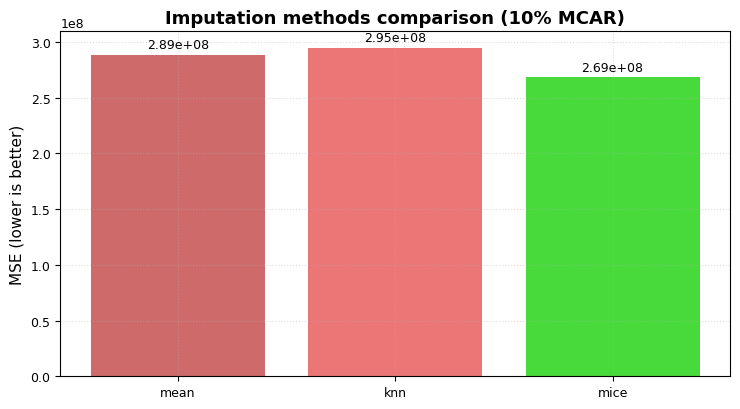

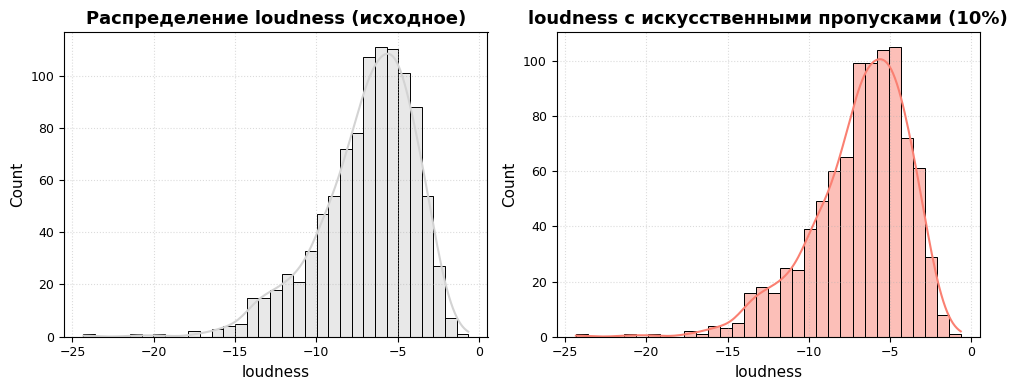

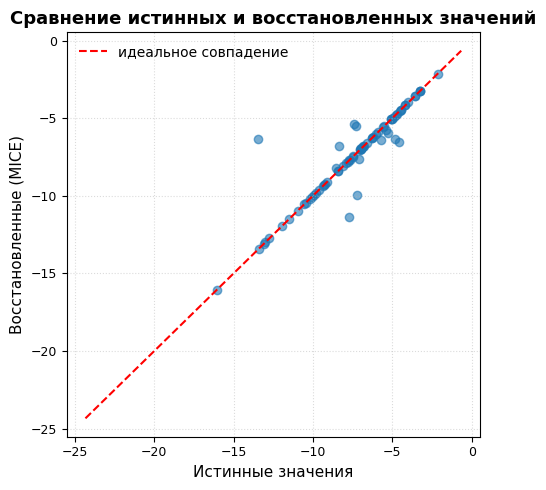

In [77]:

from sklearn.experimental import enable_iterative_imputer  # noqa: F401
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.metrics import mean_squared_error

df_num = df[num_cols].dropna().copy()
sample_n = min(1000, len(df_num))
rng = np.random.default_rng(42)
sub = df_num.sample(sample_n, random_state=42)

miss_rate = 0.1
missing_mask = rng.random(sub.shape) < miss_rate
sub_missing = sub.mask(missing_mask)

imputers = {
    "mean": SimpleImputer(strategy="mean"),
    "knn": KNNImputer(n_neighbors=5),
    "mice": IterativeImputer(random_state=42, max_iter=10),
}
scores = {}
imputed_store = {}
for name, imp in imputers.items():
    imputed = pd.DataFrame(imp.fit_transform(sub_missing), columns=sub.columns, index=sub.index)
    imputed_store[name] = imputed
    mse_list = []
    for j, c in enumerate(sub.columns):
        mpos = missing_mask[:, j]
        if mpos.sum() > 0:
            mse_list.append(mean_squared_error(sub.loc[mpos, c], imputed.loc[mpos, c]))
    scores[name] = float(np.mean(mse_list)) if mse_list else np.nan

mse_df = pd.Series(scores, name="MSE").to_frame()
display(mse_df)

plt.figure()
plt.bar(mse_df.index, mse_df["MSE"], color=["#cf6a6a","#eb7676","#48da3a"])
plt.ylabel("MSE (lower is better)")
plt.title("Imputation methods comparison (10% MCAR)")
for i, v in enumerate(mse_df["MSE"].values):
    plt.text(i, v*1.01, f"{v:.2e}", ha="center", va="bottom", fontsize=9)
plt.tight_layout()
plt.savefig("картинки/imputation_methods_python.png")

plt.show()


# Визуализация пропусков до и после импутации
import seaborn as sns

col = "loudness" if "loudness" in df_num.columns else num_cols[0]

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(sub[col], kde=True, color="lightgray")
plt.title(f"Распределение {col} (исходное)")

plt.subplot(1, 2, 2)
sns.histplot(sub_missing[col], kde=True, color="salmon")
plt.title(f"{col} с искусственными пропусками (10%)")

plt.tight_layout()
plt.savefig("картинки/imputation_before_after.png", dpi=150)
plt.show()

# Сравнение истинных и восстановленных значений для одного признака
plt.figure(figsize=(5,5))
plt.scatter(sub.loc[missing_mask[:, 0], col],
            imputed.loc[missing_mask[:, 0], col], alpha=0.6)
plt.xlabel("Истинные значения")
plt.ylabel("Восстановленные (MICE)")
plt.title("Сравнение истинных и восстановленных значений")
plt.plot([sub[col].min(), sub[col].max()],
         [sub[col].min(), sub[col].max()], 'r--', label="идеальное совпадение")
plt.legend()
plt.tight_layout()
plt.savefig("картинки/imputation_scatter.png", dpi=150)
plt.show()




## 6–7) Нормальность: тесты + Q–Q графики с огибающей + гистограммы

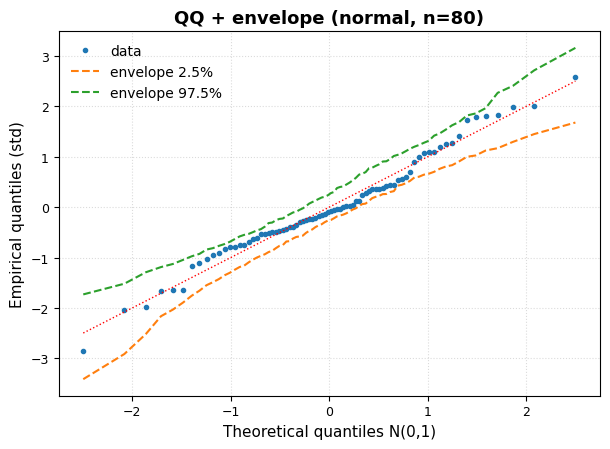

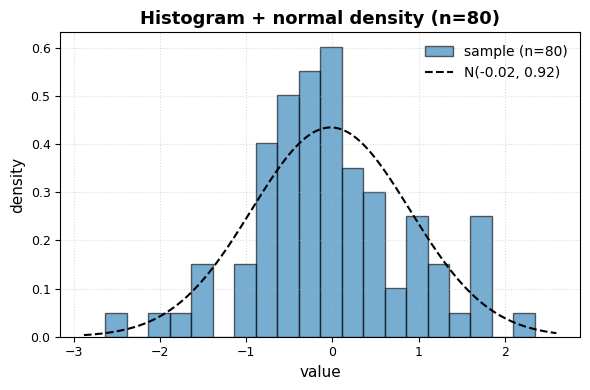

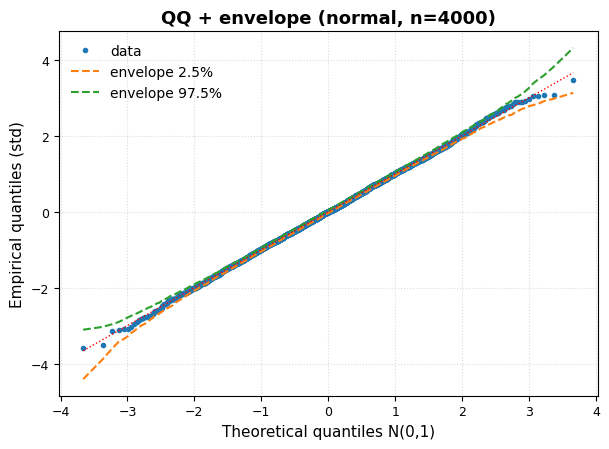

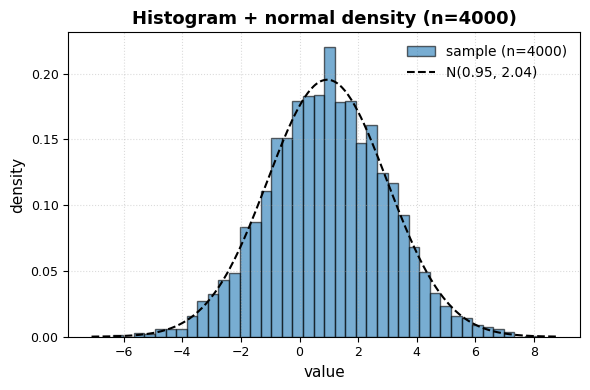

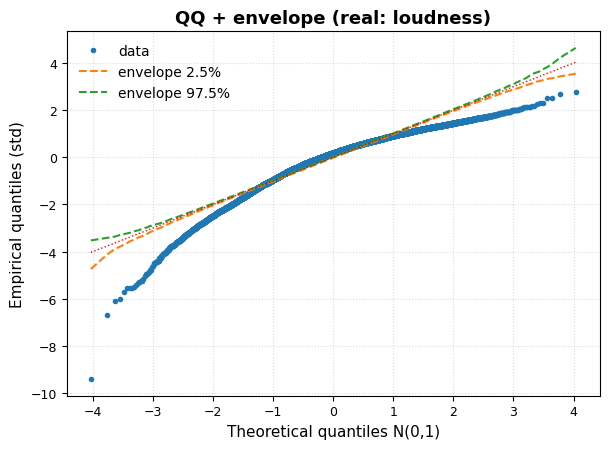

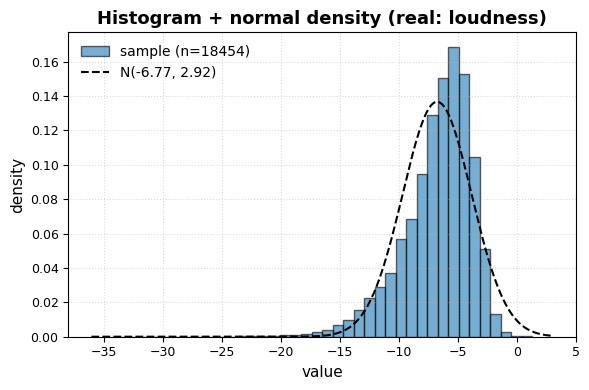

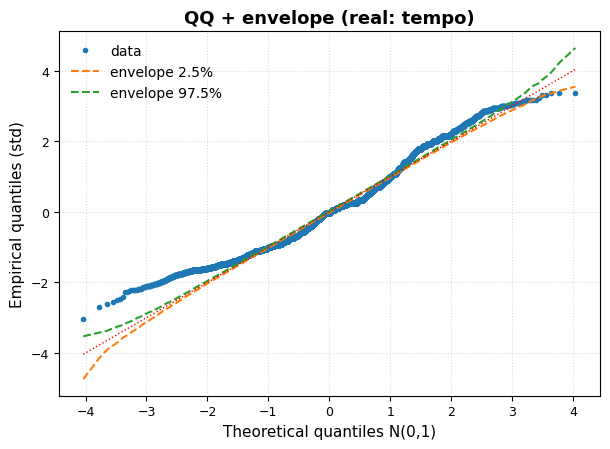

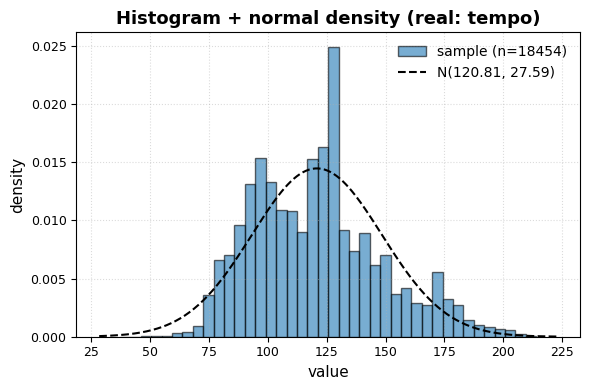

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

os.makedirs("картинки", exist_ok=True)


def qq_with_envelope(x, title=None, filename=None, nsim=200, random_state=0):
    rng = np.random.default_rng(random_state)
    x = np.asarray(pd.Series(x).dropna())
    if x.std(ddof=1) == 0 or len(x) < 10:
        print("Not enough variation/size for QQ.")
        return

    x_std = (x - x.mean()) / x.std(ddof=1)
    n = len(x_std)

    osm = np.sort(stats.norm.ppf((np.arange(1, n+1) - 0.5) / n))

    sims = np.sort(rng.normal(size=(nsim, n)), axis=1)
    lo = np.percentile(sims, 2.5, axis=0)
    hi = np.percentile(sims, 97.5, axis=0)

    plt.figure(figsize=(6.2, 4.6))
    plt.plot(osm, np.sort(x_std), ".", label="data")
    plt.plot(osm, lo, "--", label="envelope 2.5%")
    plt.plot(osm, hi, "--", label="envelope 97.5%")
    plt.plot([osm.min(), osm.max()], [osm.min(), osm.max()], "r:", lw=1)
    if title:
        plt.title(title)
    plt.xlabel("Theoretical quantiles N(0,1)")
    plt.ylabel("Empirical quantiles (std)")
    plt.legend()
    plt.tight_layout()

    if filename:
        plt.savefig(f"картинки/{filename}", dpi=150, bbox_inches="tight")

    plt.show()
    plt.close()


def hist_with_norm(x, title, filename):
    mu, sigma = np.mean(x), np.std(x, ddof=1)

    plt.figure(figsize=(6,4))
    bins = 20 if len(x) < 200 else 40
    plt.hist(x, bins=bins, density=True, alpha=0.6,
             edgecolor="black", label=f"sample (n={len(x)})")

    xmin, xmax = plt.xlim()
    xs = np.linspace(xmin, xmax, 300)
    plt.plot(xs, stats.norm.pdf(xs, mu, sigma),
             "k--", label=f"N({mu:.2f}, {sigma:.2f})")

    plt.title(title)
    plt.xlabel("value")
    plt.ylabel("density")
    plt.legend()
    plt.tight_layout()

    plt.savefig(f"картинки/{filename}", dpi=150, bbox_inches="tight")

    plt.show()
    plt.close()



small = np.random.normal(0, 1, 80)
moder = np.random.normal(1, 2, 4000)

qq_with_envelope(
    small,
    "QQ + envelope (normal, n=80)",
    filename="qq_envelope_small_py.png"
)
hist_with_norm(
    small,
    "Histogram + normal density (n=80)",
    "hist_small_py.png"
)

qq_with_envelope(
    moder,
    "QQ + envelope (normal, n=4000)",
    filename="qq_envelope_moder_py.png"
)
hist_with_norm(
    moder,
    "Histogram + normal density (n=4000)",
    "hist_moder_py.png"
)


if "loudness" in df.columns:
    qq_with_envelope(
        df["loudness"],
        "QQ + envelope (real: loudness)",
        filename="qq_envelope_loudness_py.png"
    )
    hist_with_norm(
        df["loudness"],
        "Histogram + normal density (real: loudness)",
        "hist_loudness_py.png"
    )

if "tempo" in df.columns:
    qq_with_envelope(
        df["tempo"],
        "QQ + envelope (real: tempo)",
        filename="qq_envelope_tempo_py.png"
    )
    hist_with_norm(
        df["tempo"],
        "Histogram + normal density (real: tempo)",
        "hist_tempo_py.png"
    )
